In [19]:
# Install R
!apt-get update -qq
!apt-get install -y r-base
!Rscript -e "install.packages('stylo', repos='https://cloud.r-project.org')"

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.2-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 103 not upgraded.
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/stylo_0.7.5.tar.gz'
Content type 'application/x-gzip' length 2517705 bytes (2.4 MB)
downloaded 2.4 MB

* installing *source* package ‘stylo’ ...
** this is package ‘stylo’ version ‘0.7.5’
** package ‘stylo’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** data
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** testing if installed package can be load

In [20]:
# Install required R packages
!R -e "install.packages('stylo', repos='http://cran.rstudio.com/')"


R version 4.5.2 (2025-10-31) -- "[Not] Part in a Rumble"
Copyright (C) 2025 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> install.packages('stylo', repos='http://cran.rstudio.com/')
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'http://cran.rstudio.com/src/contrib/stylo_0.7.5.tar.gz'
Content type 'application/x-gzip' length 2517705 bytes (2.4 MB)
downloaded 2.4 MB

* installing *so

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
!Rscript -e "remove.packages('stylo')"
!Rscript -e "install.packages('https://cran.r-project.org/src/contrib/Archive/stylo/stylo_0.7.4.tar.gz', repos=NULL, type='source')"

Removing package from ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.r-project.org/src/contrib/Archive/stylo/stylo_0.7.4.tar.gz'
Content type 'application/x-gzip' length 2517085 bytes (2.4 MB)
downloaded 2.4 MB

* installing *source* package ‘stylo’ ...
** this is package ‘stylo’ version ‘0.7.4’
** package ‘stylo’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** data
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (stylo)


In [ ]:
%%bash
cat > make_delta_matrix.R <<'RSCRIPT'
library(stylo)

corpus_path <- "stylo_texts" #Pfad richtig angeben

if (!dir.exists(corpus_path)) stop(paste("Corpus folder not found:", corpus_path))
txt_files <- list.files(corpus_path, pattern="\\.txt$", full.names=TRUE)
if (length(txt_files) == 0) stop(paste("No .txt files found in:", corpus_path))

# --- Headless/bug workarounds: define names used internally by stylo() ---
distance.name.on.graph <- "Burrows' Delta"
distance.name.on.file  <- "burrows_delta"
# Some versions also use these internally:
analysis.type.on.graph <- "table"
analysis.type.on.file  <- "table"

# --- Run stylo only to get frequency tables; suppress plotting side-effects ---
res <- stylo(
  gui = FALSE,
  corpus.dir = corpus_path,
  analysis.type = "table.of.frequencies",
  mfw.min = 100,
  mfw.max = 100,
  sampling = "no.sampling",
  relative.frequencies = TRUE,
  write.png.file = FALSE,
  write.svg.file = FALSE,
  save.pdf.file = FALSE
)

# Grab table + MFW list (you already confirmed these exist in res)
freq <- res$table.with.all.freqs
mfw <- res$features.actually.used

freq_mfw <- freq[, colnames(freq) %in% mfw, drop = FALSE]
cat("Docs:", nrow(freq_mfw), " | Features kept:", ncol(freq_mfw), "\n")

# Z-scores per feature across documents
z <- scale(freq_mfw)

# Burrows' Delta: mean abs diff of z-vectors
n <- nrow(z)
delta_mat <- matrix(0, n, n, dimnames = list(rownames(z), rownames(z)))

for (i in 1:n) {
  for (j in 1:n) {
    delta_mat[i, j] <- mean(abs(z[i, ] - z[j, ]), na.rm = TRUE)
  }
}

write.csv(delta_mat, file = "delta_matrix.csv", row.names = TRUE)
cat("✅ Wrote delta_matrix.csv\n")
RSCRIPT

Rscript make_delta_matrix.R

Docs: 8  | Features kept: 100 
✅ Wrote delta_matrix.csv



### stylo version: 0.7.4 ###

If you plan to cite this software (please do!), use the following reference:
    Eder, M., Rybicki, J. and Kestemont, M. (2016). Stylometry with R:
    a package for computational text analysis. R Journal 8(1): 107-121.
    <https://journal.r-project.org/archive/2016/RJ-2016-007/index.html>

To get full BibTeX entry, type: citation("stylo")
Warning message:
no DISPLAY variable so Tk is not available 
using current directory...
Performing no sampling (using entire text as sample)

slicing input text into tokens...


turning words into features, e.g. char n-grams (if applicable)...

Total nr. of samples in the corpus: 8

The corpus consists of 1950 tokens

processing  8  text samples

combining frequencies into a table...


culling @ 0	available features (words) 776
MFW used: 
100 
Processing metadata...


Assigning plot colors according to file names...

 


In [36]:
import pandas as pd
delta = pd.read_csv("delta_matrix.csv", index_col=0)
print(delta.shape)
delta.head()

(8, 8)


,Text1_1 Andersen,Text1_2 KI Andersen,Text2_1 KI Andersen,Text2_2 Andersen,Text3_1 KI Tieck,Text3_2 Tieck,Text4_1 Tieck,Text4_2 KI Tieck
Text1_1 Andersen,0.000000,0.985885,1.181935,1.166726,0.948814,0.831450,1.224244,1.108847
Text1_2 KI Andersen,0.985885,0.000000,0.883784,1.208645,0.846608,0.898661,1.091304,0.838464
Text2_1 KI Andersen,1.181935,0.883784,0.000000,0.983589,1.113579,1.075129,1.135756,1.005144
Text2_2 Andersen,1.166726,1.208645,0.983589,0.000000,1.341725,1.227863,1.170621,1.251299
Text3_1 KI Tieck,0.948814,0.846608,1.113579,1.341725,0.000000,0.847627,1.087622,0.787585


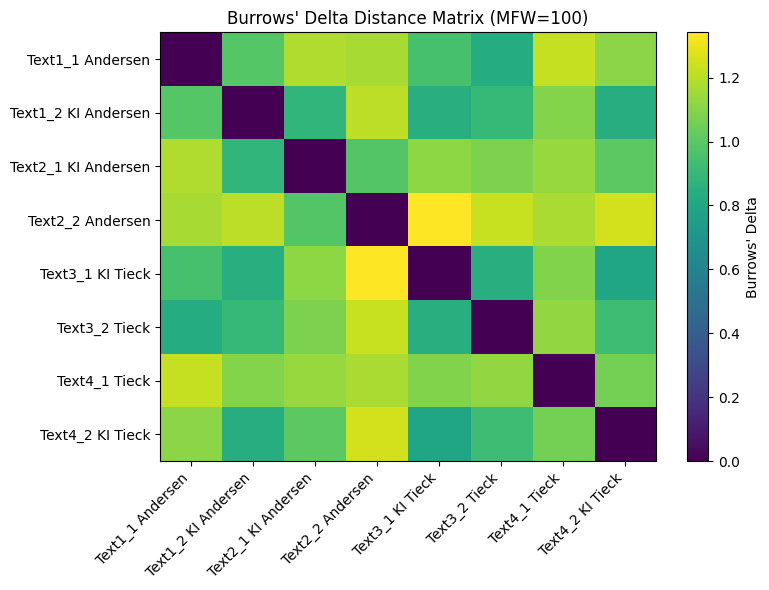

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(delta.values, aspect="auto")
ax.set_xticks(range(len(delta.columns)))
ax.set_yticks(range(len(delta.index)))
ax.set_xticklabels(delta.columns, rotation=45, ha="right")
ax.set_yticklabels(delta.index)
fig.colorbar(im, ax=ax).set_label("Burrows' Delta")
ax.set_title("Burrows' Delta Distance Matrix (MFW=100)")
plt.tight_layout()
plt.show()

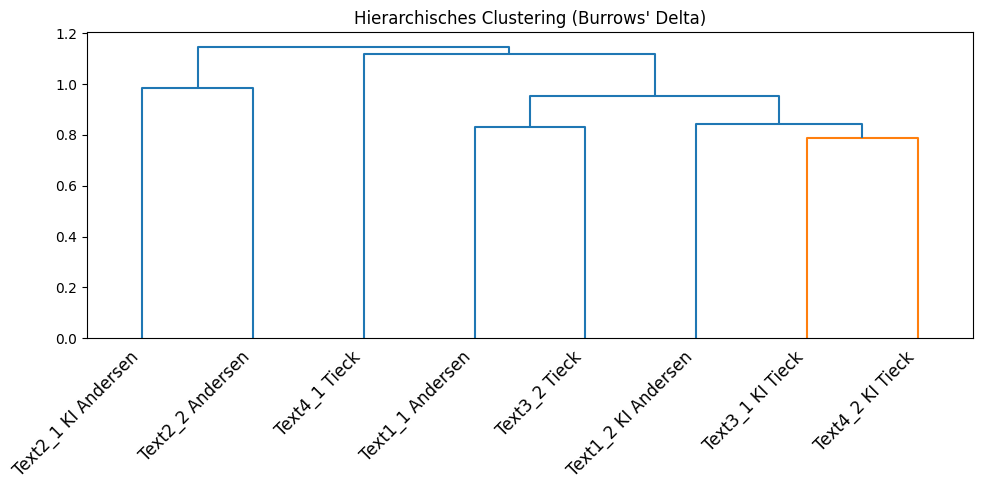

In [39]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

condensed = squareform(delta.values)
Z = linkage(condensed, method="average")

plt.figure(figsize=(10,5))
dendrogram(Z, labels=delta.index.tolist())
plt.title("Hierarchisches Clustering (Burrows' Delta)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [40]:
import numpy as np

names = delta.index.tolist()
ki = [n for n in names if "KI" in n]
human = [n for n in names if "KI" not in n]

def upper_triangle_vals(group):
    vals = []
    for i in range(len(group)):
        for j in range(i+1, len(group)):
            vals.append(delta.loc[group[i], group[j]])
    return np.array(vals, dtype=float)

def between_vals(g1, g2):
    vals = []
    for a in g1:
        for b in g2:
            vals.append(delta.loc[a, b])
    return np.array(vals, dtype=float)

ki_ki = upper_triangle_vals(ki)
hu_hu = upper_triangle_vals(human)
ki_hu = between_vals(ki, human)

print("KI:", ki)
print("Mensch:", human)
print()
print("Mean KI–KI:", ki_ki.mean())
print("Mean Mensch–Mensch:", hu_hu.mean())
print("Mean KI–Mensch:", ki_hu.mean())

KI: ['Text1_2 KI Andersen', 'Text2_1 KI Andersen', 'Text3_1 KI Tieck', 'Text4_2 KI Tieck']
Mensch: ['Text1_1 Andersen', 'Text2_2 Andersen', 'Text3_2 Tieck', 'Text4_1 Tieck']

Mean KI–KI: 0.9125275726980399
Mean Mensch–Mensch: 1.1243145867601443
Mean KI–Mensch: 1.070944237455024


/tmp/ipython-input-400/1805301916.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


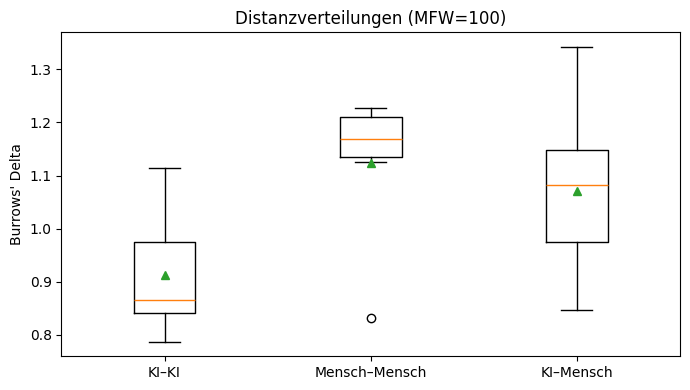

In [41]:
import matplotlib.pyplot as plt

data = [ki_ki, hu_hu, ki_hu]
labels = ["KI–KI", "Mensch–Mensch", "KI–Mensch"]

plt.figure(figsize=(7,4))
plt.boxplot(data, labels=labels, showmeans=True)
plt.ylabel("Burrows' Delta")
plt.title("Distanzverteilungen (MFW=100)")
plt.tight_layout()
plt.show()

In [42]:
import pandas as pd
import numpy as np

# Datei laden
delta = pd.read_csv("/content/delta_matrix.csv", index_col=0)

print("Shape:", delta.shape)
print("\nMatrix preview:")
print(delta)

print("\nMin value:", np.min(delta.values))
print("Max value:", np.max(delta.values))

print("\nDiagonal values:")
print(np.diag(delta.values))

Shape: (8, 8)

Matrix preview:
                     Text1_1 Andersen  Text1_2 KI Andersen  \
Text1_1 Andersen             0.000000             0.985885   
Text1_2 KI Andersen          0.985885             0.000000   
Text2_1 KI Andersen          1.181935             0.883784   
Text2_2 Andersen             1.166726             1.208645   
Text3_1 KI Tieck             0.948814             0.846608   
Text3_2 Tieck                0.831450             0.898661   
Text4_1 Tieck                1.224244             1.091304   
Text4_2 KI Tieck             1.108847             0.838464   

                     Text2_1 KI Andersen  Text2_2 Andersen  Text3_1 KI Tieck  \
Text1_1 Andersen                1.181935          1.166726          0.948814   
Text1_2 KI Andersen             0.883784          1.208645          0.846608   
Text2_1 KI Andersen             0.000000          0.983589          1.113579   
Text2_2 Andersen                0.983589          0.000000          1.341725   
Text3_1 KI

In [43]:
import numpy as np

names = delta.index.tolist()
ki = [n for n in names if "KI" in n]
human = [n for n in names if "KI" not in n]

def upper_triangle_vals(group):
    vals = []
    for i in range(len(group)):
        for j in range(i+1, len(group)):
            vals.append(delta.loc[group[i], group[j]])
    return np.array(vals, dtype=float)

def between_vals(g1, g2):
    vals = []
    for a in g1:
        for b in g2:
            vals.append(delta.loc[a, b])
    return np.array(vals, dtype=float)

ki_ki = upper_triangle_vals(ki)
hu_hu = upper_triangle_vals(human)
ki_hu = between_vals(ki, human)

print("Mean KI–KI:", ki_ki.mean())
print("Mean Mensch–Mensch:", hu_hu.mean())
print("Mean KI–Mensch:", ki_hu.mean())

Mean KI–KI: 0.9125275726980399
Mean Mensch–Mensch: 1.1243145867601443
Mean KI–Mensch: 1.070944237455024


In [44]:
import numpy as np

def dist(a, b):
    return float(delta.loc[a, b])

print("Andersen (human):",
      dist("Text1_1 Andersen", "Text2_2 Andersen"))

print("KI Andersen:",
      dist("Text1_2 KI Andersen", "Text2_1 KI Andersen"))

print("Tieck (human):",
      dist("Text3_2 Tieck", "Text4_1 Tieck"))

print("KI Tieck:",
      dist("Text3_1 KI Tieck", "Text4_2 KI Tieck"))

Andersen (human): 1.166726450683
KI Andersen: 0.883784454075808
Tieck (human): 1.12498203421108
KI Tieck: 0.787584842048468
